Token Reduction: 36.73%
ACE reduces token usage by improving semantic convergence.


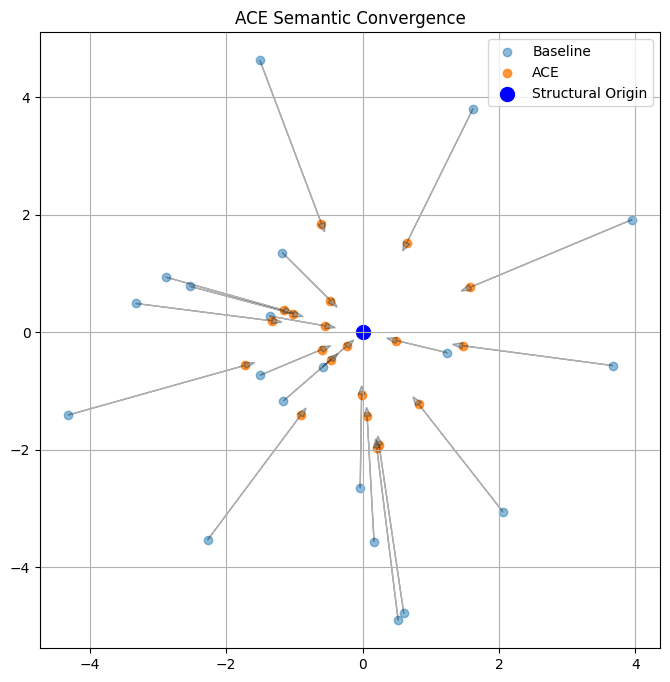

In [1]:
# ACE Semantic Convergence Demo
# Ernesto Rosati — 2026

"""
This notebook demonstrates the core principle of ACE:

Semantic stability emerges from structural grounding.

We simulate:
- Baseline semantic vectors (high dispersion)
- ACE-adjusted vectors (origin-aware convergence)

Key observation:
Lower origin cost O(z) → fewer tokens → higher stability
"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# 1. Generate baseline vectors
# -----------------------------
N = 20
baseline = np.random.randn(N, 2) * 2.5  # high dispersion

# Structural origin (shared premise)
origin = np.array([0.0, 0.0])

# -----------------------------
# 2. ACE transformation
# -----------------------------
def ace_transform(vectors, alpha=0.6):
    # Move vectors toward origin (simulate O(z) minimization)
    return vectors - alpha * (vectors - origin)

ace_vectors = ace_transform(baseline)

# -----------------------------
# 3. Token simulation
# -----------------------------
def simulate_tokens(vectors):
    # More distance from origin → more tokens
    dist = np.linalg.norm(vectors, axis=1)
    return 20 + dist * 10

tokens_baseline = simulate_tokens(baseline)
tokens_ace = simulate_tokens(ace_vectors)

reduction = (tokens_baseline.mean() - tokens_ace.mean()) / tokens_baseline.mean() * 100

print(f"Token Reduction: {reduction:.2f}%")
if reduction > 0:
    print("ACE reduces token usage by improving semantic convergence.")

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(8,8))

# Baseline
plt.scatter(baseline[:,0], baseline[:,1], label="Baseline", alpha=0.5)

# ACE vectors
plt.scatter(ace_vectors[:,0], ace_vectors[:,1], label="ACE", alpha=0.8)

# Arrows
for i in range(N):
    plt.arrow(
        baseline[i,0], baseline[i,1],
        ace_vectors[i,0] - baseline[i,0],
        ace_vectors[i,1] - baseline[i,1],
        head_width=0.1, alpha=0.3
    )

# Origin
plt.scatter(0, 0, c='blue', s=100, label="Structural Origin")

plt.title("ACE Semantic Convergence")
plt.legend()
plt.grid()
plt.show()